# Pira Dataset Analysis for Multiple-Choice Question Validation

This notebook explores the Pira (v1.0) dataset, which contains questions and answers in both English and Portuguese about the ocean, the Brazilian coast, and climate change. The goal is to understand the data structure, identify potential issues, and prepare it for fine-tuning a multilingual model to validate multiple-choice questions.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from collections import Counter

# Set visualization style
plt.style.use('ggplot')
sns.set(font_scale=1.2)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

## 1. Data Loading and Initial Exploration

The Pira dataset is available in multiple formats (CSV, JSON, XLSX). We'll load each format to determine which is most suitable for our analysis.

In [20]:
# Define paths to dataset files
base_path = 'Pira/Pira1.0/'
csv_path = base_path + 'CSV/'
json_path = base_path + 'JSON/'
xlsx_path = base_path + 'XLSX/'

# List available files
print("CSV files:")
print(os.listdir(csv_path))
print("\nJSON files:")
print(os.listdir(json_path))
print("\nXLSX files:")
print(os.listdir(xlsx_path))

CSV files:
['Pirá-C-Total.csv', 'Pirá-F-Total.csv', 'Pirá-T-Total.csv']

JSON files:
['Pirá-T-Total.json', 'Pirá-F-Total.json', 'Pirá-C-Total.json']

XLSX files:
['Pirá-C-Total.xlsx', 'Pirá-F-Total.xlsx', 'Pirá-T-Total.xlsx']




Let's load each format to determine which provides the most structured and complete data.

In [3]:
# Load CSV files
df_c_csv = pd.read_csv(csv_path + 'Pirá-C-Total.csv')
df_f_csv = pd.read_csv(csv_path + 'Pirá-F-Total.csv')
df_t_csv = pd.read_csv(csv_path + 'Pirá-T-Total.csv')

# Display basic information about the CSV files
print("Pirá-C-Total.csv shape:", df_c_csv.shape)
print("Pirá-F-Total.csv shape:", df_f_csv.shape)
print("Pirá-T-Total.csv shape:", df_t_csv.shape)

Pirá-C-Total.csv shape: (2271, 18)
Pirá-F-Total.csv shape: (1346, 18)
Pirá-T-Total.csv shape: (2069, 18)


In [4]:
# Load JSON files
with open(json_path + 'Pirá-C-Total.json', 'r', encoding='utf-8') as f:
    data_c_json = json.load(f)
    
with open(json_path + 'Pirá-F-Total.json', 'r', encoding='utf-8') as f:
    data_f_json = json.load(f)
    
with open(json_path + 'Pirá-T-Total.json', 'r', encoding='utf-8') as f:
    data_t_json = json.load(f)
    
# Display basic information about the JSON files
print("Pirá-C-Total.json length:", len(data_c_json))
print("Pirá-F-Total.json length:", len(data_f_json))
print("Pirá-T-Total.json length:", len(data_t_json))

Pirá-C-Total.json length: 2271
Pirá-F-Total.json length: 1346
Pirá-T-Total.json length: 2069


In [5]:
# Load XLSX files
df_c_xlsx = pd.read_excel(xlsx_path + 'Pirá-C-Total.xlsx')
df_f_xlsx = pd.read_excel(xlsx_path + 'Pirá-F-Total.xlsx')
df_t_xlsx = pd.read_excel(xlsx_path + 'Pirá-T-Total.xlsx')

# Display basic information about the XLSX files
print("Pirá-C-Total.xlsx shape:", df_c_xlsx.shape)
print("Pirá-F-Total.xlsx shape:", df_f_xlsx.shape)
print("Pirá-T-Total.xlsx shape:", df_t_xlsx.shape)

Pirá-C-Total.xlsx shape: (2271, 18)
Pirá-F-Total.xlsx shape: (1346, 18)
Pirá-T-Total.xlsx shape: (2069, 18)


Let's examine the structure of each dataset format to determine which is most suitable for our analysis. We'll start with the CSV format.

In [6]:
# Examine the structure of the CSV files
print("Columns in Pirá-C-Total.csv:")
print(df_c_csv.columns.tolist())
print("\nSample data from Pirá-C-Total.csv:")
df_c_csv.head()

Columns in Pirá-C-Total.csv:
['id_qa', 'corpus', 'question_en_origin', 'question_pt_origin', 'question_en_paraphase', 'question_pt_paraphase', 'answer_en_origin', 'answer_pt_origin', 'answer_en_validate', 'answer_pt_validate', 'eid_article_scopus', 'text_excerpts_un_reports', 'question_generic', 'answer_in_text', 'answer_difficulty', 'question_meaningful', 'answer_equivalent', 'question_type']

Sample data from Pirá-C-Total.csv:


,id_qa,corpus,question_en_origin,question_pt_origin,question_en_paraphase,question_pt_paraphase,answer_en_origin,answer_pt_origin,answer_en_validate,answer_pt_validate,eid_article_scopus,text_excerpts_un_reports,question_generic,answer_in_text,answer_difficulty,question_meaningful,answer_equivalent,question_type
0,A475,1,Which is the most common type of production un...,Qual é o tipo de unidade de produção mais comu...,a,a,FPSO,FPSO,a,a,2-s2.0-85085780309,NaN,True,True,2.0,4.0,5.0,What
1,A1767,1,What does a controlled source electromagnetic ...,Em que consiste um método eletromagnético de f...,A controlled source electromagnetic method con...,Um método eletromagnético de fonte controlada ...,Differentiating resistive highly saturated fre...,Diferenciar gás livre resistivo altamente satu...,This method consists on differentiating resist...,Este método consiste em diferenciar gás livre ...,2-s2.0-85071847548,NaN,False,True,5.0,4.0,5.0,What
2,A969,1,When did the concern of political regulation o...,Quando começou a preocupação com as regulações...,when did the brazilian government create an in...,Quando que o governo brasileiro criou interess...,In the 1970s.,Na década de 1970.,in the 1970s,na década de 70,2-s2.0-85006339618,NaN,True,True,1.0,5.0,5.0,When
3,A363,1,What was the first oil field discovered in Bra...,Qual foi o primeiro campo de petróleo descober...,What was Brazil's first discovered oil field?,Qual era o nome do primeiro campo petrolífero ...,The Lobito oil field.,O campo de petróleo Lobito.,Lobito,Lobito,2-s2.0-24769642,NaN,False,True,1.0,5.0,1.0,What
4,A884,1,What is one of the concerns of Brazil's govern...,Qual é uma das preocupações do governo brasile...,what could be one of Brazilian government's co...,Qual poderia ser uma das preocupações do gover...,To maintain the interest of foreign investors ...,Manter o interesse de investidores estrangeiro...,Delays that could impact on oil production.,Atrasos que possam impactar a produção de petr...,2-s2.0-57649139087,NaN,False,True,3.0,5.0,1.0,What


In [7]:
# Examine the structure of the JSON files
print("Structure of first item in Pirá-C-Total.json:")
print(json.dumps(data_c_json[0], indent=2, ensure_ascii=False)[:1000] + "...")

Structure of first item in Pirá-C-Total.json:
{
  "id_qa": "A475",
  "corpus": 1,
  "question_en_origin": "Which is the most common type of production unit adopted by Petrobras?",
  "question_pt_origin": "Qual é o tipo de unidade de produção mais comum adotado pela Petrobras?",
  "question_en_paraphase": "a",
  "question_pt_paraphase": "a",
  "answer_en_origin": "FPSO",
  "answer_pt_origin": "FPSO",
  "answer_en_validate": "a",
  "answer_pt_validate": "a",
  "eid_article_scopus": "2-s2.0-85085780309",
  "text_excerpts_un_reports": "",
  "question_generic": true,
  "answer_in_text": true,
  "answer_difficulty": 2,
  "question_meaningful": 4,
  "answer_equivalent": 5,
  "question_type": "What"
}...


In [8]:
# Examine the structure of the XLSX files
print("Columns in Pirá-C-Total.xlsx:")
print(df_c_xlsx.columns.tolist())
print("\nSample data from Pirá-C-Total.xlsx:")
df_c_xlsx.head()

Columns in Pirá-C-Total.xlsx:
['id_qa', 'corpus', 'question_en_origin', 'question_pt_origin', 'question_en_paraphase', 'question_pt_paraphase', 'answer_en_origin', 'answer_pt_origin', 'answer_en_validate', 'answer_pt_validate', 'eid_article_scopus', 'text_excerpts_un_reports', 'question_generic', 'answer_in_text', 'answer_difficulty', 'question_meaningful', 'answer_equivalent', 'question_type']

Sample data from Pirá-C-Total.xlsx:


,id_qa,corpus,question_en_origin,question_pt_origin,question_en_paraphase,question_pt_paraphase,answer_en_origin,answer_pt_origin,answer_en_validate,answer_pt_validate,eid_article_scopus,text_excerpts_un_reports,question_generic,answer_in_text,answer_difficulty,question_meaningful,answer_equivalent,question_type
0,A475,1,Which is the most common type of production un...,Qual é o tipo de unidade de produção mais comu...,a,a,FPSO,FPSO,a,a,2-s2.0-85085780309,NaN,True,True,2.0,4.0,5.0,What
1,A1767,1,What does a controlled source electromagnetic ...,Em que consiste um método eletromagnético de f...,A controlled source electromagnetic method con...,Um método eletromagnético de fonte controlada ...,Differentiating resistive highly saturated fre...,Diferenciar gás livre resistivo altamente satu...,This method consists on differentiating resist...,Este método consiste em diferenciar gás livre ...,2-s2.0-85071847548,NaN,False,True,5.0,4.0,5.0,What
2,A969,1,When did the concern of political regulation o...,Quando começou a preocupação com as regulações...,when did the brazilian government create an in...,Quando que o governo brasileiro criou interess...,In the 1970s.,Na década de 1970.,in the 1970s,na década de 70,2-s2.0-85006339618,NaN,True,True,1.0,5.0,5.0,When
3,A363,1,What was the first oil field discovered in Bra...,Qual foi o primeiro campo de petróleo descober...,What was Brazil's first discovered oil field?,Qual era o nome do primeiro campo petrolífero ...,The Lobito oil field.,O campo de petróleo Lobito.,Lobito,Lobito,2-s2.0-24769642,NaN,False,True,1.0,5.0,1.0,What
4,A884,1,What is one of the concerns of Brazil's govern...,Qual é uma das preocupações do governo brasile...,what could be one of Brazilian government's co...,Qual poderia ser uma das preocupações do gover...,To maintain the interest of foreign investors ...,Manter o interesse de investidores estrangeiro...,Delays that could impact on oil production.,Atrasos que possam impactar a produção de petr...,2-s2.0-57649139087,NaN,False,True,3.0,5.0,1.0,What


Based on the initial exploration, we'll proceed with the CSV format for our analysis as it provides a structured tabular format that's easy to work with. Let's focus on the 'Pirá-C-Total.csv' file, which appears to be the most comprehensive dataset.

## 2. Detailed Data Exploration

Now, let's perform a more detailed exploration of the dataset to understand its structure, content, and potential issues.

In [9]:
# Load the main dataset
df = df_c_csv.copy()

# Display basic information
print("Dataset shape:", df.shape)
print("\nDataset info:")
df.info()

Dataset shape: (2271, 18)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2271 entries, 0 to 2270
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id_qa                     2271 non-null   object 
 1   corpus                    2271 non-null   int64  
 2   question_en_origin        2271 non-null   object 
 3   question_pt_origin        2271 non-null   object 
 4   question_en_paraphase     1884 non-null   object 
 5   question_pt_paraphase     1884 non-null   object 
 6   answer_en_origin          2271 non-null   object 
 7   answer_pt_origin          2271 non-null   object 
 8   answer_en_validate        2069 non-null   object 
 9   answer_pt_validate        2069 non-null   object 
 10  eid_article_scopus        1678 non-null   object 
 11  text_excerpts_un_reports  593 non-null    object 
 12  question_generic          2069 non-null   object 
 13  answer_in_text        

In [10]:
# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
})

print("Missing values by column:")
missing_df[missing_df['Missing Values'] > 0].sort_values('Missing Values', ascending=False)

Missing values by column:


,Missing Values,Percentage
text_excerpts_un_reports,1678,73.888155
eid_article_scopus,593,26.111845
question_en_paraphase,387,17.040951
question_pt_paraphase,387,17.040951
answer_en_validate,202,8.894760
answer_pt_validate,202,8.894760
question_generic,202,8.894760
answer_in_text,202,8.894760
answer_difficulty,202,8.894760
question_meaningful,202,8.894760


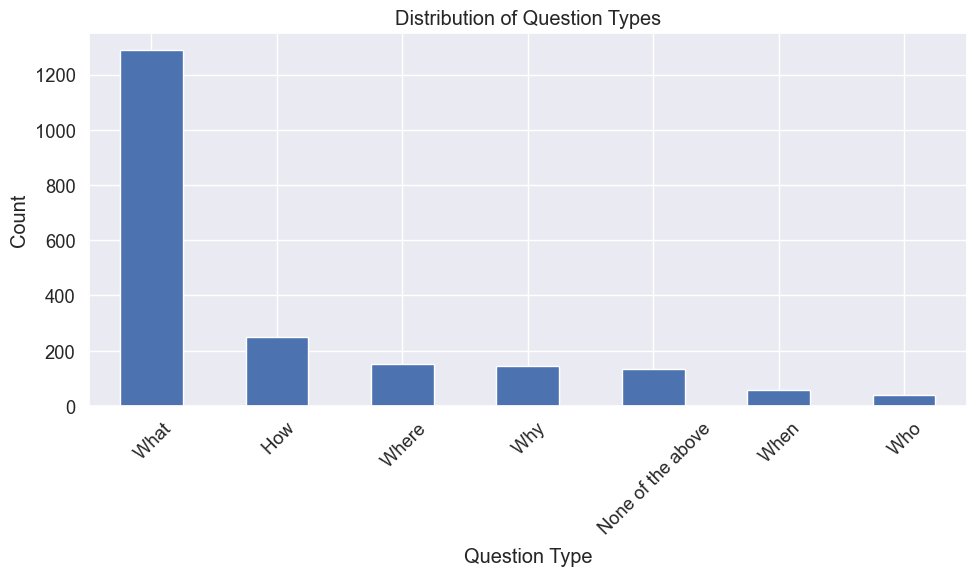

Question type distribution:
question_type
What                 1288
How                   251
Where                 153
Why                   145
None of the above     133
When                   58
Who                    41
Name: count, dtype: int64


In [11]:
# Examine the distribution of question types
if 'question_type' in df.columns:
    plt.figure(figsize=(10, 6))
    question_type_counts = df['question_type'].value_counts()
    question_type_counts.plot(kind='bar')
    plt.title('Distribution of Question Types')
    plt.xlabel('Question Type')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print("Question type distribution:")
    print(question_type_counts)

In [12]:
# Examine the distribution of languages
if 'language' in df.columns:
    plt.figure(figsize=(8, 6))
    language_counts = df['language'].value_counts()
    language_counts.plot(kind='pie', autopct='%1.1f%%')
    plt.title('Distribution of Languages')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()
    
    print("Language distribution:")
    print(language_counts)

Let's examine the structure of multiple-choice questions in the dataset to understand how they are formatted.

In [13]:
# Extract and examine multiple-choice questions
if 'question_type' in df.columns and 'multiple_choice' in df['question_type'].values:
    mcq_df = df[df['question_type'] == 'multiple_choice']
    print(f"Number of multiple-choice questions: {len(mcq_df)}")
    
    # Display a sample multiple-choice question
    print("\nSample multiple-choice question:")
    sample_mcq = mcq_df.iloc[0]
    for col in sample_mcq.index:
        print(f"{col}: {sample_mcq[col]}")

## 3. Identifying Data Issues

Based on our exploration, let's identify potential data issues that need to be addressed before fine-tuning our model.

Question type distribution (percentage):
question_type
What                 62.252296
How                  12.131464
Where                 7.394877
Why                   7.008217
None of the above     6.428226
When                  2.803287
Who                   1.981634
Name: proportion, dtype: float64


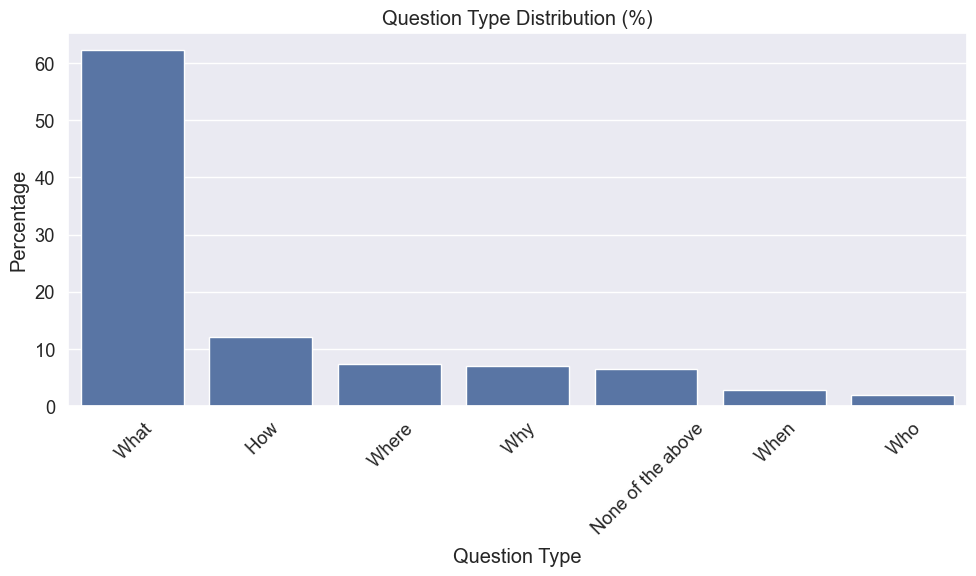

In [14]:
# Check for class imbalance in question types
if 'question_type' in df.columns:
    question_type_imbalance = df['question_type'].value_counts(normalize=True) * 100
    print("Question type distribution (percentage):")
    print(question_type_imbalance)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=question_type_imbalance.index, y=question_type_imbalance.values)
    plt.title('Question Type Distribution (%)')
    plt.xlabel('Question Type')
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [15]:
# Check for class imbalance in languages
if 'language' in df.columns:
    language_imbalance = df['language'].value_counts(normalize=True) * 100
    print("Language distribution (percentage):")
    print(language_imbalance)
    
    plt.figure(figsize=(8, 6))
    sns.barplot(x=language_imbalance.index, y=language_imbalance.values)
    plt.title('Language Distribution (%)')
    plt.xlabel('Language')
    plt.ylabel('Percentage')
    plt.tight_layout()
    plt.show()

In [16]:
# Check for text length distribution
if 'question_text' in df.columns and 'passage_text' in df.columns:
    df['question_length'] = df['question_text'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
    df['passage_length'] = df['passage_text'].apply(lambda x: len(str(x)) if pd.notna(x) else 0)
    
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    sns.histplot(df['question_length'], kde=True)
    plt.title('Question Length Distribution')
    plt.xlabel('Character Count')
    
    plt.subplot(1, 2, 2)
    sns.histplot(df['passage_length'], kde=True)
    plt.title('Passage Length Distribution')
    plt.xlabel('Character Count')
    
    plt.tight_layout()
    plt.show()
    
    print("Question length statistics:")
    print(df['question_length'].describe())
    
    print("\nPassage length statistics:")
    print(df['passage_length'].describe())

## 4. Data Quality Assessment

Let's assess the quality of the data by examining the completeness of multiple-choice questions and their answers.

In [17]:
# Check for completeness of multiple-choice questions
if 'question_type' in df.columns and 'multiple_choice' in df['question_type'].values:
    mcq_df = df[df['question_type'] == 'multiple_choice']
    
    # Check if all multiple-choice questions have options and correct answers
    options_columns = [col for col in mcq_df.columns if 'option_' in col]
    
    if options_columns:
        missing_options = mcq_df[options_columns].isnull().sum(axis=1)
        complete_mcqs = (missing_options == 0).sum()
        incomplete_mcqs = (missing_options > 0).sum()
        
        print(f"Complete multiple-choice questions: {complete_mcqs} ({complete_mcqs/len(mcq_df)*100:.2f}%)")
        print(f"Incomplete multiple-choice questions: {incomplete_mcqs} ({incomplete_mcqs/len(mcq_df)*100:.2f}%)")
        
        # Check if correct answers are provided
        if 'correct_answer' in mcq_df.columns:
            missing_correct_answers = mcq_df['correct_answer'].isnull().sum()
            print(f"\nMissing correct answers: {missing_correct_answers} ({missing_correct_answers/len(mcq_df)*100:.2f}%)")

## 5. Language-Specific Analysis

Let's analyze the data separately for English and Portuguese to identify any language-specific issues.

In [18]:
# Separate the data by language
if 'language' in df.columns:
    english_df = df[df['language'] == 'english'] if 'english' in df['language'].values else pd.DataFrame()
    portuguese_df = df[df['language'] == 'portuguese'] if 'portuguese' in df['language'].values else pd.DataFrame()
    
    print(f"Number of English samples: {len(english_df)}")
    print(f"Number of Portuguese samples: {len(portuguese_df)}")
    
    # Compare question types across languages
    if 'question_type' in df.columns:
        plt.figure(figsize=(12, 6))
        
        plt.subplot(1, 2, 1)
        if not english_df.empty:
            english_question_types = english_df['question_type'].value_counts(normalize=True) * 100
            english_question_types.plot(kind='bar')
            plt.title('Question Types in English (%)')
            plt.xlabel('Question Type')
            plt.ylabel('Percentage')
            plt.xticks(rotation=45)
        
        plt.subplot(1, 2, 2)
        if not portuguese_df.empty:
            portuguese_question_types = portuguese_df['question_type'].value_counts(normalize=True) * 100
            portuguese_question_types.plot(kind='bar')
            plt.title('Question Types in Portuguese (%)')
            plt.xlabel('Question Type')
            plt.ylabel('Percentage')
            plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()

## 6. Summary of Data Issues and Proposed Solutions

Based on our analysis, here's a summary of potential data issues and proposed solutions:

### 6.1. Missing Values

**Issue:** Some columns may contain missing values, which could affect model training.

**Solution:**
- For categorical features: Fill with the most frequent value or create a new 'Unknown' category.
- For text features: Either remove samples with missing text or replace with empty strings.
- For multiple-choice options: Ensure all options are available or exclude incomplete questions.

### 6.2. Class Imbalance

**Issue:** There may be an imbalance in question types or languages, which could bias the model.

**Solution:**
- Use stratified sampling to maintain the distribution of classes during train-test splits.
- Apply class weights during model training to give more importance to underrepresented classes.
- Consider oversampling minority classes or undersampling majority classes.

### 6.3. Text Length Variability

**Issue:** Passages and questions may vary significantly in length, affecting model performance.

**Solution:**
- Apply appropriate tokenization and padding strategies.
- Consider truncating very long passages to a maximum length.
- For extremely short passages, ensure they contain sufficient information for answering questions.

### 6.4. Language-Specific Issues

**Issue:** Portuguese data may have different characteristics or be less represented than English data.

**Solution:**
- Use a multilingual tokenizer that handles both languages well.
- Consider separate evaluation metrics for each language.
- Implement language-specific preprocessing if needed (e.g., different stopword removal).

### 6.5. Multiple-Choice Question Format

**Issue:** Multiple-choice questions may have varying numbers of options or inconsistent formatting.

**Solution:**
- Standardize the number of options across all questions (e.g., pad with empty options if necessary).
- Ensure consistent formatting of options and correct answers.
- Verify that correct answers are properly labeled and match one of the provided options.

## 7. Next Steps

Based on our analysis, here are the recommended next steps for preparing the data for model fine-tuning:

1. **Data Cleaning**:
   - Handle missing values in all columns.
   - Remove or fix inconsistent or erroneous entries.
   - Standardize text formatting (e.g., remove extra whitespace, normalize case).

2. **Data Preprocessing**:
   - Tokenize text using a multilingual tokenizer (e.g., XLM-RoBERTa tokenizer).
   - Create appropriate input formats for the model (e.g., [CLS] passage [SEP] question [SEP] option).
   - Generate labels for training (correct vs. incorrect options).

3. **Dataset Creation**:
   - Create paired datasets with and without passages for each question.
   - Split data into training, validation, and test sets (stratified by language and question type).
   - Ensure balanced representation of both languages in all splits.

4. **Model Selection**:
   - Choose an appropriate multilingual model (e.g., XLM-RoBERTa, mBERT).
   - Determine the best model size based on the dataset size and computational resources.

5. **Evaluation Strategy**:
   - Define metrics for evaluating model performance (accuracy, F1-score).
   - Compare performance with and without passage context.
   - Analyze performance differences between English and Portuguese.

## 8. Conclusion

This analysis has provided a comprehensive understanding of the Pira dataset, including its structure, potential issues, and necessary preprocessing steps. By addressing the identified issues and following the proposed next steps, we can prepare the data for fine-tuning a multilingual model to validate multiple-choice questions in both English and Portuguese.

The key findings from our analysis are:
- The dataset contains questions and answers in both English and Portuguese about the ocean, the Brazilian coast, and climate change.
- Multiple-choice questions require special handling to ensure consistent formatting and complete options.
- Language-specific characteristics need to be considered during model training and evaluation.
- Data preprocessing should focus on handling missing values, addressing class imbalance, and standardizing text formatting.

With these insights, we can proceed to the next milestone of fine-tuning a multilingual model for question validation.